In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../../Data.csv")
data = data.drop(columns=["VD", "VE", "tempo"])
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    for preds in PREDICTORS:
        sns.lineplot(x=df.index, y=df[preds], ax=ax1, marker="o", label=preds,  linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        for target in TARGET:
            sns.lineplot(x=df.index, y=df[target], ax=ax2, marker="o", label=target, linestyle="dashed", linewidth=2, color="red")
            ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Exibindo o gráfico
    plt.show()


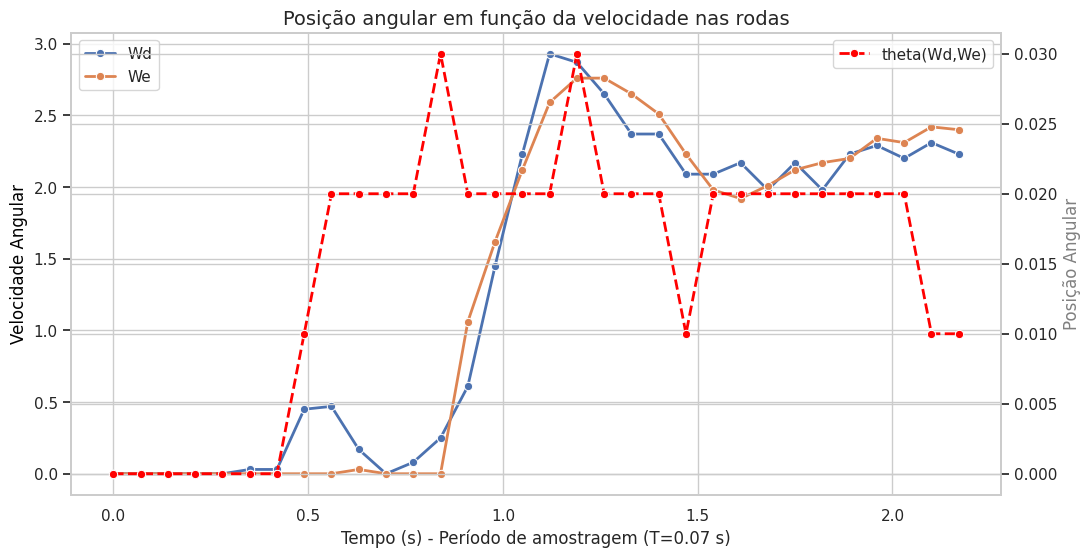

In [9]:
PlotTimeSeries(data.head(32))

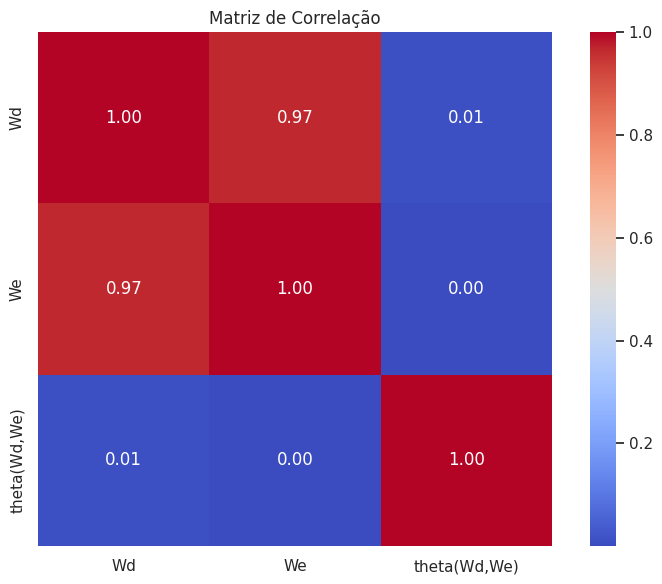

In [10]:

# Define os nomes das colunas
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

# Subconjunto dos dados com preditores e target
corr_data = data[PREDICTORS + [TARGET]]

# Calcula a matriz de correlação
corr_matrix = corr_data.corr()

# Exibe a matriz de correlação com seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from sklearn.preprocessing import StandardScaler
from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping

class EvalRNN:
    
    def __init__(self, Dataset, units, batchSize=32):
        
        self.units = units
        self.batchSize = batchSize
                
        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)
        train_data, val_data = train_test_split(train_data, test_size=0.15, shuffle=False)
                
        self.train_samples_x = np.array(train_data[PREDICTORS])
        self.train_samples_y = np.array(train_data[TARGET])
        
        self.val_samples_x = np.array(val_data[PREDICTORS])
        self.val_samples_y = np.array(val_data[TARGET])
        
        self.test_samples_x = np.array(test_data[PREDICTORS])
        self.test_samples_y = np.array(test_data[TARGET])
    
        # self.h0 = np.zeros((self.batchSize, self.units))

        self.train_time = Dataset.head(np.size(self.train_samples_y)).index
    
    def CompileModel(self, model, epochs=100):
        model.compile(loss="mse", optimizer="adam")

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        history = model.fit(
            self.train_samples_x, self.train_samples_y,
            epochs=epochs,
            validation_data=(self.val_samples_x, self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            batch_size=self.batchSize
        )

        return history.history['val_loss'][-1]  # Retorna o último MSE da validação

    def Evaluate(self):
        inputs = layers.Input(shape=(self.train_samples_x.shape[1], 1), batch_size=self.batchSize) 
        
        rnn_layer = layers.SimpleRNN(
            self.units,
            return_sequences=False,
            kernel_regularizer=regularizers.l2(0.01),
            # stateful=True,
        )
        
        # rnn_output = rnn_layer(inputs, initial_state=[self.h0])
        rnn_output = rnn_layer(inputs)

        outputs = layers.Dense(1, kernel_regularizer=regularizers.l2(0.01))(rnn_output)

        model = models.Model(inputs, outputs)

        self.CompileModel(model, epochs=100)

        metrics = self.ComputeMetrics(model)
        print(metrics)

        df = pd.DataFrame([metrics])
        df.to_excel('metrics.xlsx', sheet_name='Results', index=False)

        self.PlotOut()  
    
    def ComputeMetrics(self, model):
        self.train_pred = model.predict(self.train_samples_x)
        self.val_pred = model.predict(self.val_samples_x)        
        self.test_pred = model.predict(self.test_samples_x)

        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })
        
    def PlotOut(self):
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))  # 3 linhas, 1 coluna

        datasets = [
            ('Treinamento', self.train_samples_y, self.train_pred),
            ('Validação', self.val_samples_y, self.val_pred),
            ('Teste', self.test_samples_y, self.test_pred)
        ]

        time_train = np.arange(len(self.train_samples_y))
        time_val = np.arange(len(self.val_samples_y))
        time_test = np.arange(len(self.test_samples_y))

        times = [time_train, time_val, time_test]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            axs[i].plot(times[i], y_pred, label='Valor Predito', color='orange', linestyle='dashed')
            axs[i].scatter(times[i], y_true, label='Amostras Reais', color='black', s=20)
            
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Tempo')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

2025-05-06 12:52:25.947091: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-06 12:52:26.196584: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-06 12:52:26.432699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746535946.801368    2534 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746535946.966486    2534 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746535947.702154    2534 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

2025-05-06 12:53:21.346847: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
{'r2_training': 0.5652579082327489, 'mse_training': 0.061875253796952676, 'mape_training': 17325295565051.602, 'rmse_training': 0.24874736942720152, 'r2_test': -63.57620002820222, 'mse_test': 1.4391699311425548, 'mape_test': 2.0724680013307286, 'rmse_test': 1.1996540881198026, 'r2_val': -127.50492519792684, 'mse_val': 0.027351072187813647, 'mape_val': 5307282047384.665, 'rmse_val': 0.16538159567440885}


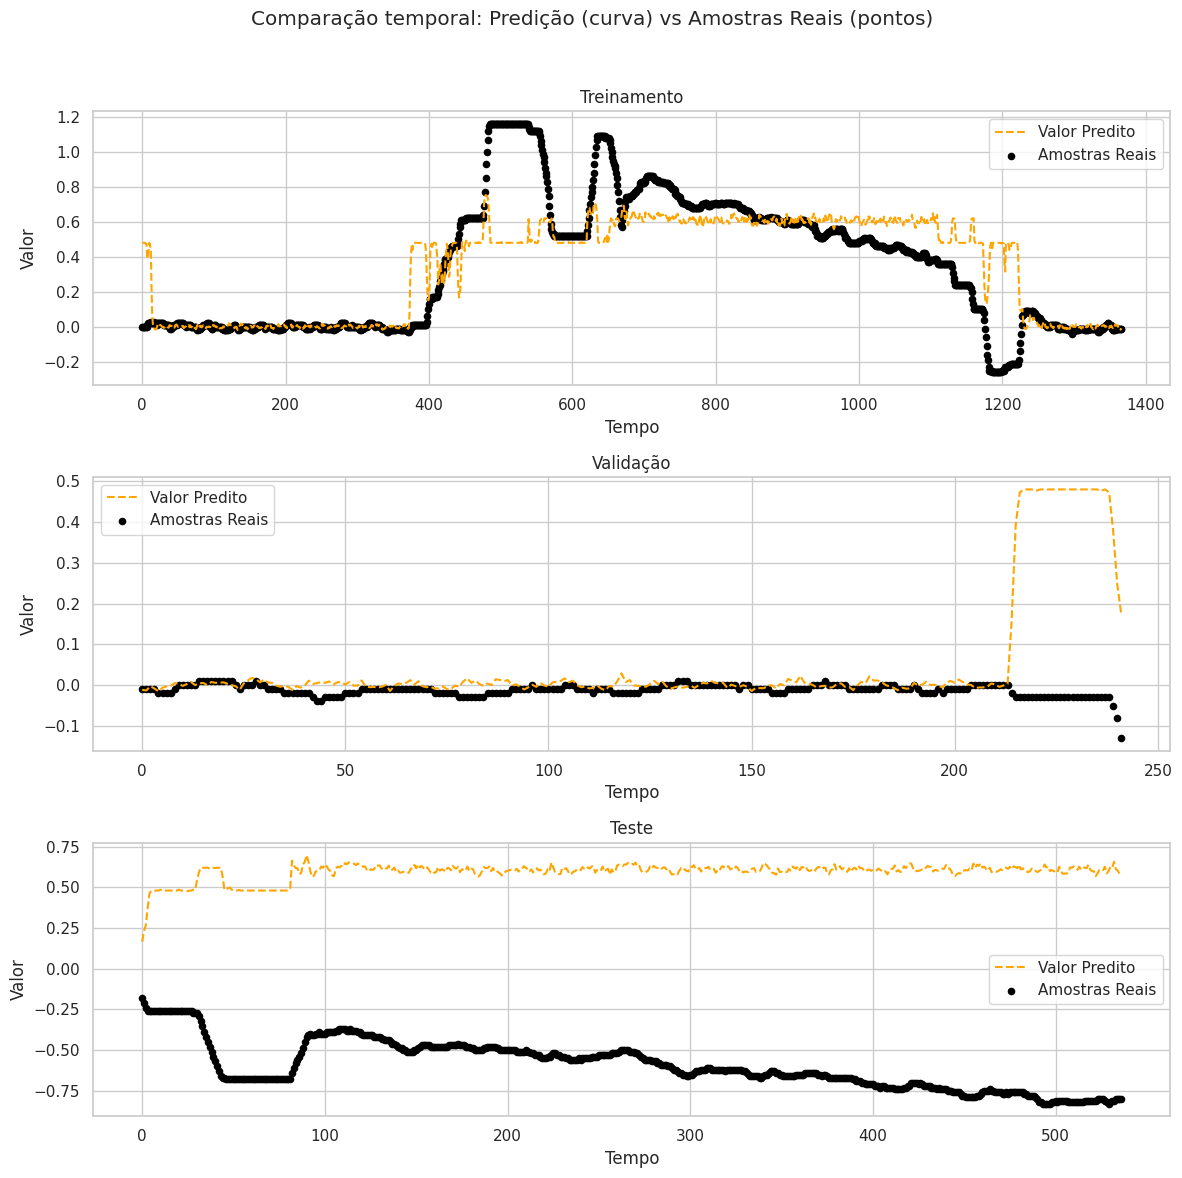

In [12]:
Vsg = EvalRNN(Dataset=data, units=10)        
Vsg.Evaluate() 

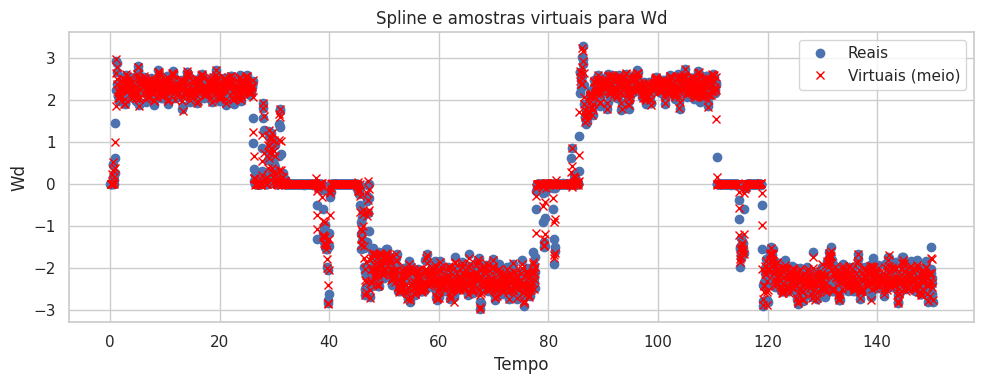

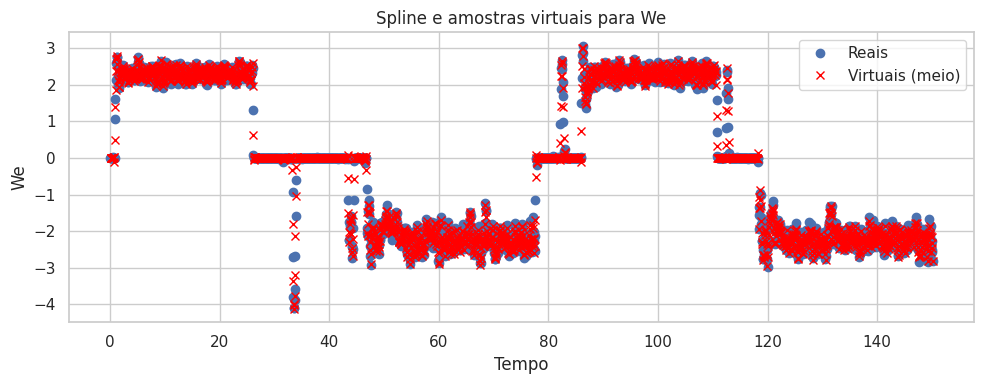

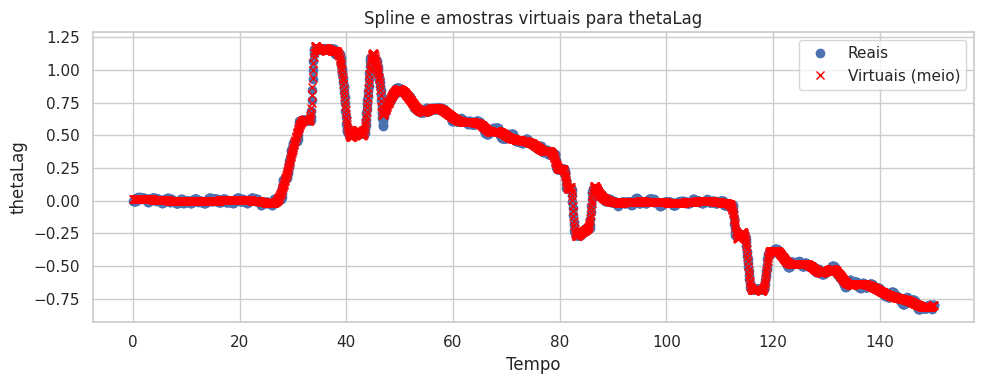

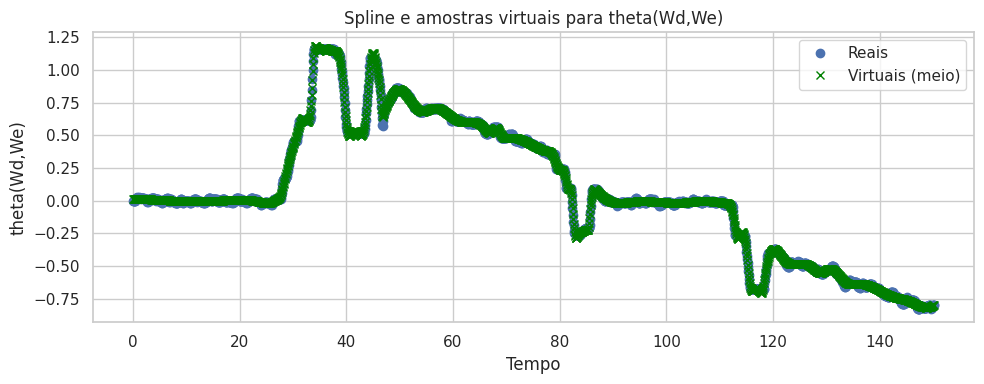

In [ ]:
from scipy.interpolate import UnivariateSpline
import pandas as pd
import matplotlib.pyplot as plt

def ComputeVirtualDim(Dataset):
    tempo = Dataset.index.to_numpy()

    # Tempo virtual: entre pares consecutivos
    tempo_virtual = ((tempo[:-1] + tempo[1:]) / 2).round(5)

    virtual_data = {
        "tempo_virtual": tempo_virtual
    }

    for pred in PREDICTORS:
        y = Dataset[pred].to_numpy()
        spline = UnivariateSpline(tempo, y, s=0.5)

        y_virtual = spline(tempo_virtual)
        virtual_data[pred] = y_virtual

        plt.figure(figsize=(10, 4))
        plt.plot(tempo, y, 'o', label='Reais')
        plt.plot(tempo_virtual, y_virtual, 'x', color='red', label='Virtuais (meio)')
        plt.xlabel("Tempo")
        plt.ylabel(pred)
        plt.title(f"Spline e amostras virtuais para {pred}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    y_target = Dataset[TARGET].to_numpy()
    spline_target = UnivariateSpline(tempo, y_target, s=0.5)
    target_virtual = spline_target(tempo_virtual)
    virtual_data[f'{TARGET}_spline'] = target_virtual

    plt.figure(figsize=(10, 4))
    plt.plot(tempo, y_target, 'o', label='Reais')
    plt.plot(tempo_virtual, target_virtual, 'x', color='green', label='Virtuais (meio)')
    plt.xlabel("Tempo")
    plt.ylabel(TARGET)
    plt.title(f"Spline e amostras virtuais para {TARGET}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(virtual_data)

VirtualDataset = ComputeVirtualDim(Dataset=data)


In [ ]:
VirtualDataset

,tempo_virtual,Wd,We,thetaLag,"theta(Wd,We)_spline"
0,0.105,-0.001309,0.000267,0.013392,0.015522
1,0.175,0.001421,0.001046,0.013410,0.015410
2,0.245,-0.005407,0.000521,0.013424,0.015297
3,0.315,0.025778,-0.000455,0.013432,0.015182
4,0.385,-0.009302,-0.001025,0.013435,0.015064
...,...,...,...,...,...
2139,149.835,-1.762927,-2.126779,-0.806898,-0.805389
2140,149.905,-1.797347,-2.153000,-0.805252,-0.803555
2141,149.975,-2.367411,-2.455179,-0.803476,-0.801583
2142,150.045,-2.464167,-2.331821,-0.801568,-0.799469


In [ ]:
    model = Vsg.models[variogram]
    virtual_samples_x = np.array(VirtualDataset[PREDICTORS])

    VirtualDataset[f'{TARGET}_{variogram}'] = model.execute('points',
                                             virtual_samples_x[:, 0],
                                             virtual_samples_x[:, 1],
                                             virtual_samples_x[:, 2])[0]
        
    


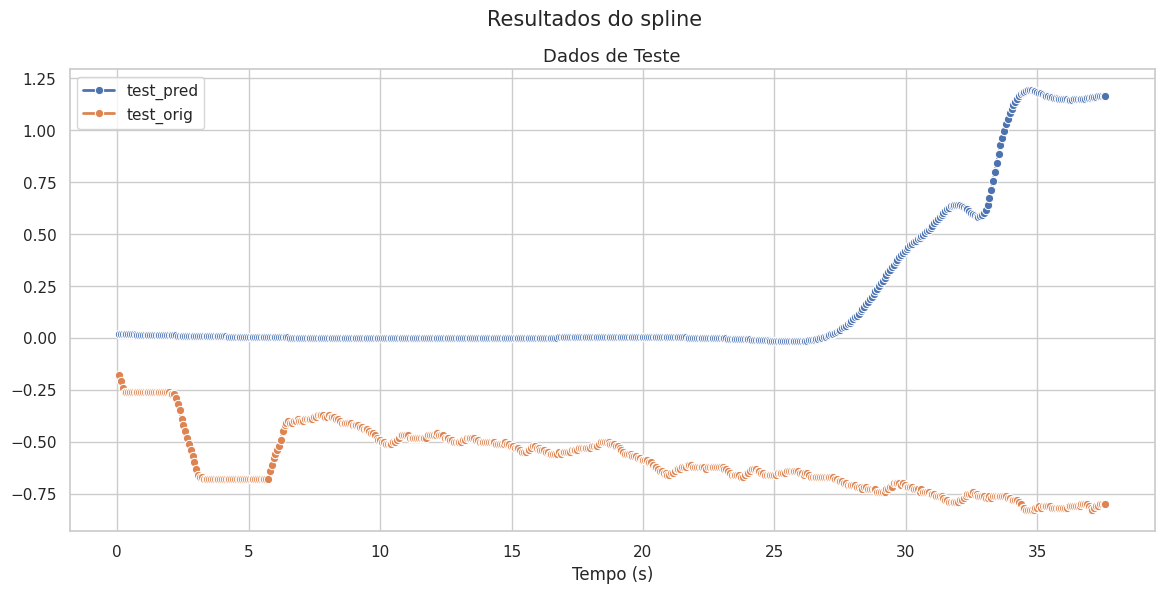

In [ ]:
train_time = data.head(np.size(Vsg.train_samples_y)).index
test_time = data.head(np.size(Vsg.test_samples_y)).index

spline = UnivariateSpline(train_time, Vsg.train_samples_y, s=0.5)
test_spline = spline(test_time)

spline_metrics = {
'r2_test': r2_score(Vsg.test_samples_y, test_spline),
'mse_test': mean_squared_error(Vsg.test_samples_y, test_spline),
'mape_test': mean_absolute_percentage_error(Vsg.test_samples_y, test_spline),
'rmse_test': root_mean_squared_error(Vsg.test_samples_y, test_spline),
}

spline_metrics_df = pd.DataFrame([spline_metrics])

# Salva em nova aba no arquivo Excel
with pd.ExcelWriter("./content/KrigingMetrics.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    spline_metrics_df.to_excel(writer, sheet_name="SplineMetrics", index=False)

sns.set_theme(style="whitegrid")

fig, ax2 = plt.subplots(1, 1, figsize=(14, 6), sharey=False)

sns.lineplot(x=test_time, y=test_spline, ax=ax2, marker="o", label="test_pred", linewidth=2)
sns.lineplot(x=test_time, y=Vsg.test_samples_y, ax=ax2, marker="o", label="test_orig", linewidth=2)
ax2.set_title("Dados de Teste", fontsize=13)
ax2.set_xlabel("Tempo (s)", fontsize=12)
ax2.legend()

fig.suptitle(f"Resultados do spline", fontsize=15)


plt.savefig(f"content/spline.svg", format="svg", dpi=600)

plt.show()

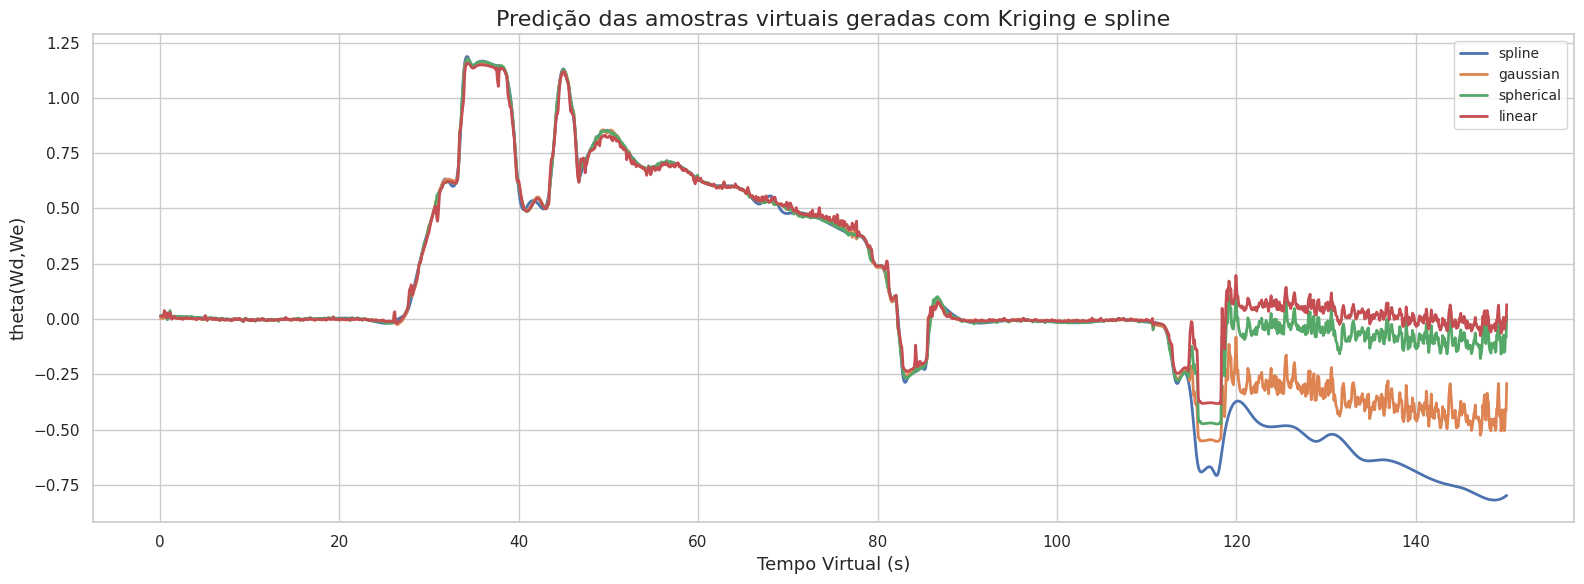

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o arquivo com as amostras virtuais
virtual_df = pd.read_excel("./content/VirtualData.xlsx")

# Define o tempo
tempo_virtual = virtual_df["tempo_virtual"]

# Define as colunas de predição
model_cols = [
    "theta(Wd,We)_spline",
    "theta(Wd,We)_gaussian",
    "theta(Wd,We)_spherical",
    # "theta(Wd,We)_hole-effect",
    # "theta(Wd,We)_power",
    "theta(Wd,We)_linear"
]

# Configura o estilo
sns.set_theme(style="whitegrid")

# Cria figura e eixos
fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot das predições (eixo esquerdo)
for col in model_cols:
    ax1.plot(tempo_virtual, virtual_df[col], label=col.split("_")[-1], linewidth=2)

ax1.set_xlabel("Tempo Virtual (s)", fontsize=13)
ax1.set_ylabel("theta(Wd,We)", fontsize=13)
ax1.legend(title="Modelo", loc="upper left")
ax1.grid(True)

# # Segundo eixo y (eixo direito) para Wd e We
# ax2 = ax1.twinx()
# ax2.plot(tempo_virtual, virtual_df["Wd"], color="black", linestyle="--", label="Wd", alpha=0.6)
# ax2.plot(tempo_virtual, virtual_df["We"], color="gray", linestyle="-.", label="We", alpha=0.6)
# ax2.set_ylabel("Wd / We", fontsize=13)

# Combina as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc="upper right", fontsize=10)

# Título e layout
plt.title("Predição das amostras virtuais geradas com Kriging e spline", fontsize=16)
plt.tight_layout()
plt.savefig("content/figs/virtualPredictions.svg", format="svg", dpi=600)
plt.show()
